# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.covariance import EmpiricalCovariance

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.viz as bviz
from osbad.database import BenchDB
from osbad.model import ModelRunner

# Import dataset

In [2]:
# Path to database directory
# "tohoku_benchmark_dataset.db" inside the database folder
DB_DIR = bconf.DB_DIR

db_filepath = DB_DIR.joinpath("tohoku_benchmark_dataset.db")

## Get unique cell labels from training dataset

* There are 10 cells in the Tohoku dataset, and in this work, we are using ``cell-1``, ``cell-2``, ``cell-5`` and ``cell-6`` for training.
* In this notebook, the example model training is illustrated for one cell: ``cell-1`` 

In [3]:
# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_tohoku_dataset").fetchdf()

# Drop the additional index column
df_duckdb = df_duckdb.drop(
    columns="__index_level_0__",
    errors="ignore")

unique_cell_index_train = df_duckdb["cell_index"].unique()
print(unique_cell_index_train)

['cell_num_1' 'cell_num_2' 'cell_num_3' 'cell_num_4' 'cell_num_5'
 'cell_num_6' 'cell_num_7' 'cell_num_8' 'cell_num_9' 'cell_num_10']


## Select data based on cell_index

In [4]:
# Get the cell-ID from cell_inventory
selected_cell_label = "cell_num_1"
cell_num = selected_cell_label[-1]

# Create a subfolder to store fig output
# corresponding to each cell-index
selected_cell_artifacts_dir = bconf.artifacts_output_dir(
    selected_cell_label)

# Filter dataset for specific selected cell only
df_selected_cell = df_duckdb[
    df_duckdb["cell_index"] == selected_cell_label]

# Import the BenchDB class
benchdb = BenchDB(
    db_filepath,
    selected_cell_label)

## Drop labels

In [5]:
# Drop the outlier labels
df_selected_cell_without_labels = df_selected_cell.drop(
    "outlier", axis=1).reset_index(drop=True)

df_selected_cell_without_labels

,discharge_capacity,voltage,cycle_index,cell_index
0,0.000077,3.617995,0,cell_num_1
1,0.231343,3.572679,0,cell_num_1
2,0.462615,3.567599,0,cell_num_1
3,0.693891,3.563376,0,cell_num_1
4,0.925169,3.559585,0,cell_num_1
...,...,...,...,...
158807,37.700096,3.067416,476,cell_num_1
158808,37.931385,3.066397,476,cell_num_1
158809,38.162678,3.065279,476,cell_num_1
158810,38.393963,3.064079,476,cell_num_1


## Plot cycle capacity fade without labels

In [6]:
# Calculate maximum capacity per cycle
max_cap_per_cycle = (
    df_selected_cell_without_labels
        .groupby(["cycle_index"])["discharge_capacity"].max())
max_cap_per_cycle.name = "max_discharge_capacity"

unique_cycle_index = (
    df_selected_cell_without_labels["cycle_index"].unique())

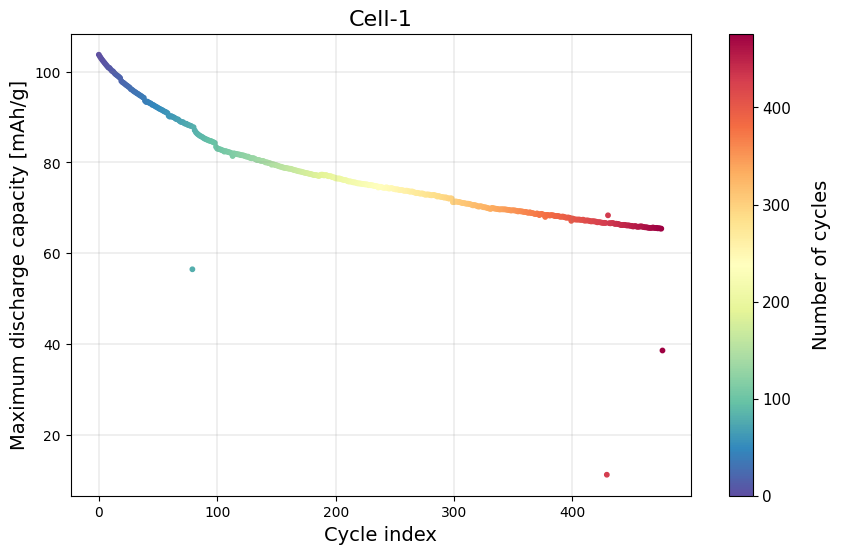

In [7]:
axplot = bviz.plot_cycle_data(
    xseries=unique_cycle_index,
    yseries=max_cap_per_cycle,
    cycle_index_series=unique_cycle_index)

axplot.set_xlabel(
    r"Cycle index",
    fontsize=14)
axplot.set_ylabel(
    r"Maximum discharge capacity [mAh/g]",
    fontsize=14)

axplot.set_title(
    f"Cell-{cell_num}",
    fontsize=16)

output_fig_filename = (
    "cycling_data_without_labels_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# Feature transformation

In the Tohoku's dataset, we want to track the sudden and unintended capacity drop over the cycle life. Therefore, for this purpose, the features we are using are

* Cycle index
* Maximum discharge capacity
* Normalized Mahalanobis distance

## Create Xfeat for Mahalanobis distance calculation

* The Mahalanobis distance is calculated from both the cycle index as well as the maximum discharge capacity.

In [8]:
df_cycle_index = pd.Series(
    unique_cycle_index,
    name="cycle_index")

# Input features for Mahalanobis distance
df_features_per_cell = pd.concat(
    [df_cycle_index,
     max_cap_per_cycle],
    axis=1)

df_features_per_cell

,cycle_index,max_discharge_capacity
0,0,103.695534
1,1,103.262245
2,2,102.863579
3,3,102.514778
4,4,102.167763
...,...,...
472,472,65.497063
473,473,65.533783
474,474,65.472183
475,475,65.430740


## Feature: Normalized Mahalanobis distance

In [9]:
Xfeat = df_features_per_cell.values

# Calculate Mahalanobis distance based on cycle_index and max_discharge_capacity
cov = EmpiricalCovariance().fit(Xfeat)
mahal_dist = cov.mahalanobis(Xfeat)

df_maha_dist = pd.Series(
    mahal_dist,
    name="mahal_dist")

# Merge calculated mahalanobis distance
df_merge_features = pd.concat(
    [df_features_per_cell,
     df_maha_dist], axis=1)

# Calculate maximum mahal_dist to
# normalize the distance calculation
max_mahal_dist = (
    df_merge_features["mahal_dist"].max())

df_merge_features["norm_mahal_dist"] = (
    df_merge_features["mahal_dist"]/max_mahal_dist)

selected_feature_cols = (
    "max_discharge_capacity",
    "norm_mahal_dist")

In [10]:
df_merge_features

,cycle_index,max_discharge_capacity,mahal_dist,norm_mahal_dist
0,0,103.695534,9.673250,0.062985
1,1,103.262245,9.211937,0.059981
2,2,102.863579,8.804678,0.057329
3,3,102.514778,8.464507,0.055114
4,4,102.167763,8.135068,0.052969
...,...,...,...,...
472,472,65.497063,4.012342,0.026125
473,473,65.533783,4.089273,0.026626
474,474,65.472183,4.116929,0.026806
475,475,65.430740,4.154986,0.027054


# Hyperparameter tuning

## Create optuna study

In [11]:
# Define the hyperparameter search space for GMM
hp_space=lambda trial: {
    "contamination": trial.suggest_float(
        "contamination", 0, 0.5),
    "n_components": trial.suggest_int(
        "n_components", 1, 5, step=1),
    "covariance_type": trial.suggest_categorical(
        "covariance_type", ["full", "tied", "diag", "spherical"]),
    "init_param": trial.suggest_categorical(
        "init_param", ["kmeans", "random"]),
    "threshold": trial.suggest_float(
        "threshold", 0, 1)}

In [12]:
# Instantiate an optuna study for iForest model
sampler = optuna.samplers.TPESampler(seed=42)

gmm_study = optuna.create_study(
    study_name="gmm_hyperparam",
    sampler=sampler,
    directions=["maximize","maximize"])

gmm_study.optimize(
    lambda trial: hp.objective(
        trial,
        model_id="gmm",
        df_feature_dataset=df_merge_features,
        selected_feature_cols=selected_feature_cols,
        df_benchmark_dataset=df_selected_cell,
        hp_space=hp_space,
        selected_cell_label=selected_cell_label),
    n_trials=20)

[I 2026-03-06 20:24:22,033] A new study created in memory with name: gmm_hyperparam
[I 2026-03-06 20:24:22,467] Trial 0 finished with values: [1.0, 0.75] and parameters: {'contamination': 0.18727005942368125, 'n_components': 5, 'covariance_type': 'full', 'init_param': 'random', 'threshold': 0.6011150117432088}.
[I 2026-03-06 20:24:22,819] Trial 1 finished with values: [0.3333333333333333, 1.0] and parameters: {'contamination': 0.35403628889802274, 'n_components': 1, 'covariance_type': 'full', 'init_param': 'random', 'threshold': 0.5247564316322378}.
[I 2026-03-06 20:24:23,203] Trial 2 finished with values: [1.0, 0.061224489795918366] and parameters: {'contamination': 0.21597250932105788, 'n_components': 2, 'covariance_type': 'full', 'init_param': 'random', 'threshold': 0.19967378215835974}.
[I 2026-03-06 20:24:23,579] Trial 3 finished with values: [0.3333333333333333, 1.0] and parameters: {'contamination': 0.2571172192068058, 'n_components': 3, 'covariance_type': 'tied', 'init_param': 

## Aggregate best trials

In [13]:
schema_gmm = {
    "contamination": "median",
    "n_components": "median_int",
    "covariance_type": "mode",
    "init_param": "mode",
    "threshold": "median",
}

df_gmm_hyperparam = hp.aggregate_best_trials(
    gmm_study.best_trials,
    cell_label=selected_cell_label,
    model_id="gmm",
    schema=schema_gmm)

df_gmm_hyperparam

,ml_model,cell_index,contamination,n_components,covariance_type,init_param,threshold
0,gmm,cell_num_1,0.216436,4,diag,kmeans,0.744088


## Evaluate percentage of perfect recall and precision score

In [14]:
recall_score_pct, precision_score_pct = hp.evaluate_hp_perfect_score_pct(
    model_study=gmm_study)

Total trial count: 20
Trial 0:
Recall score per trial: 1.0
Precision score per trial: 0.75
----------------------------------------------------------------------
Trial 1:
Recall score per trial: 0.3333333333333333
Precision score per trial: 1.0
----------------------------------------------------------------------
Trial 2:
Recall score per trial: 1.0
Precision score per trial: 0.061224489795918366
----------------------------------------------------------------------
Trial 3:
Recall score per trial: 0.3333333333333333
Precision score per trial: 1.0
----------------------------------------------------------------------
Trial 4:
Recall score per trial: 0.3333333333333333
Precision score per trial: 1.0
----------------------------------------------------------------------
Trial 5:
Recall score per trial: 0.3333333333333333
Precision score per trial: 1.0
----------------------------------------------------------------------
Trial 6:
Recall score per trial: 1.0
Precision score per trial: 1.

## Plot pareto front

/home/mei-chin-pang/02_academics/osbad_development/osbad/src/osbad/hyperparam.py:1012: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  axplot = optuna.visualization.matplotlib.plot_pareto_front(


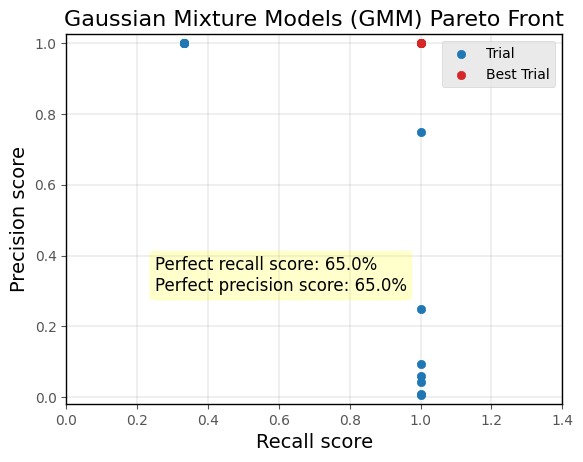

In [15]:
hp.plot_pareto_front(
    gmm_study,
    selected_cell_label,
    fig_title="Gaussian Mixture Models (GMM) Pareto Front")

plt.show()

## Export current hyperparameters to CSV 

In [16]:
# Export current hyperparameters to CSV
hyperparam_filepath =  Path.cwd().joinpath(
    "hp_03_gmm_hyperparam_tohoku.csv")

hp.export_current_hyperparam(
    df_gmm_hyperparam,
    selected_cell_label,
    export_csv_filepath=hyperparam_filepath,
    if_exists="replace")

Have the hyperparam for cell_num_1 been evaluated?
True
**********************************************************************
Replacing existing rows for cell_num_1.
Hyperparameters for cell_num_1 have been replaced in the CSV file.


,ml_model,cell_index,contamination,n_components,covariance_type,init_param,threshold
0,gmm,cell_num_1,0.216436,4,diag,kmeans,0.744088


# Train model with best trial parameters

## Load best trial parameters from CSV output

In [17]:
# Test reading from exported metrics
df_hyperparam_from_csv = pd.read_csv(hyperparam_filepath)

df_param_per_cell = df_hyperparam_from_csv[
    df_hyperparam_from_csv["cell_index"] == selected_cell_label]
df_param_per_cell

,ml_model,cell_index,contamination,n_components,covariance_type,init_param,threshold
0,gmm,cell_num_1,0.216436,4,diag,kmeans,0.744088


## Create a dict for best trial parameters

In [18]:
param_dict = df_param_per_cell.iloc[0].to_dict()
pprint.pp(param_dict)

{'ml_model': 'gmm',
 'cell_index': 'cell_num_1',
 'contamination': 0.2164356328798363,
 'n_components': 4,
 'covariance_type': 'diag',
 'init_param': 'kmeans',
 'threshold': 0.7440882575488279}


## Run the model with best trial parameters

In [19]:
cfg = hp.MODEL_CONFIG["gmm"]

runner = ModelRunner(
    cell_label=selected_cell_label,
    df_input_features=df_merge_features,
    selected_feature_cols=selected_feature_cols
)

Xdata = runner.create_model_x_input()

model = cfg.model_param(param_dict)
print(model)
model.fit(Xdata)
proba = model.predict_proba(Xdata)

pred_outlier_indices, pred_outlier_score = runner.pred_outlier_indices_from_proba(
    proba=proba,
    threshold=param_dict["threshold"],
    outlier_col=cfg.proba_col
)

pred_outlier_indices, pred_outlier_score

GMM(contamination=0.2164356328798363, covariance_type='diag',
  init_params='kmeans', max_iter=100, means_init=None, n_components=4,
  n_init=1, precisions_init=None, random_state=42, reg_covar=1e-06,
  tol=0.001, warm_start=False, weights_init=None)


(array([ 79, 429, 476]), array([0.91459432, 1.        , 0.88944655]))

## Get df_outliers_pred

In [20]:
df_outliers_pred = (df_merge_features[
    df_merge_features["cycle_index"]
    .isin(pred_outlier_indices)].copy())

df_outliers_pred["outlier_prob"] = pred_outlier_score
df_outliers_pred

,cycle_index,max_discharge_capacity,mahal_dist,norm_mahal_dist,outlier_prob
79,79,56.489555,53.625261,0.349166,0.914594
429,429,11.293598,153.580929,1.000000,1.000000
476,476,38.625252,29.740101,0.193644,0.889447


## Predict anomaly score map

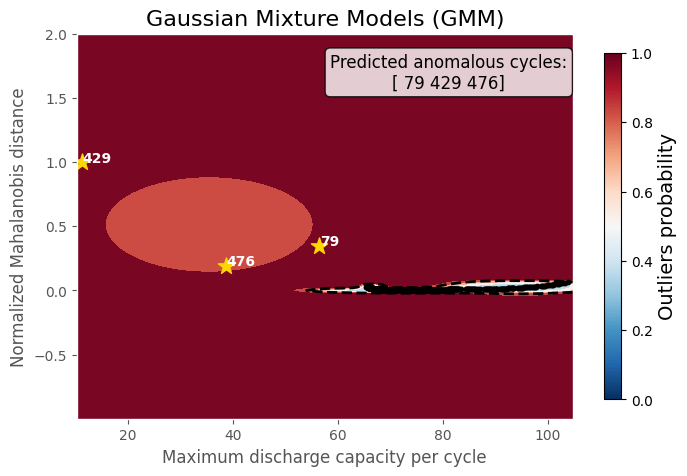

In [21]:
grid_offset_size = 1

axplot = runner.predict_anomaly_score_map(
    selected_model=model,
    model_name="Gaussian Mixture Models (GMM)",
    xoutliers=df_outliers_pred["max_discharge_capacity"],
    youtliers=df_outliers_pred["norm_mahal_dist"],
    pred_outliers_index=pred_outlier_indices,
    threshold=param_dict["threshold"],
    square_grid=False,
    grid_offset=grid_offset_size
)

axplot.set_xlabel(
    r"Maximum discharge capacity per cycle",
    fontsize=12)
axplot.set_ylabel(
    r"Normalized Mahalanobis distance",
    fontsize=12)

output_fig_filename = (
    f"gmm_grid_offset_size_{grid_offset_size}_" 
    + selected_cell_label 
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

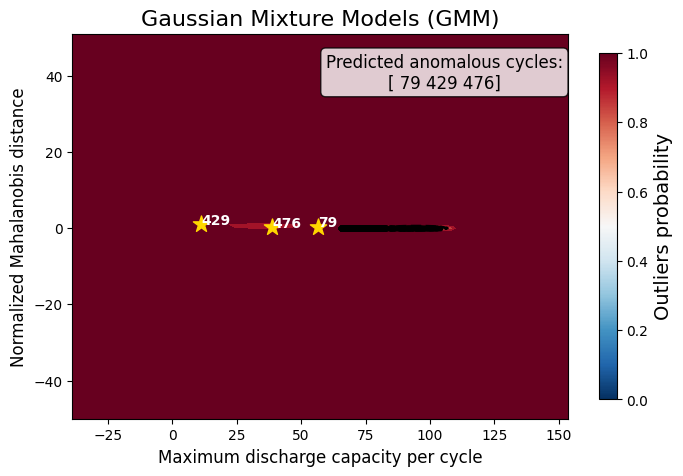

In [22]:
grid_offset_size = 50

axplot = runner.predict_anomaly_score_map(
    selected_model=model,
    model_name="Gaussian Mixture Models (GMM)",
    xoutliers=df_outliers_pred["max_discharge_capacity"],
    youtliers=df_outliers_pred["norm_mahal_dist"],
    pred_outliers_index=pred_outlier_indices,
    threshold=param_dict["threshold"],
    square_grid=False,
    grid_offset=grid_offset_size
)

axplot.set_xlabel(
    r"Maximum discharge capacity per cycle",
    fontsize=12)
axplot.set_ylabel(
    r"Normalized Mahalanobis distance",
    fontsize=12)

output_fig_filename = (
    f"gmm_grid_offset_size_{grid_offset_size}_" 
    + selected_cell_label 
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# Model performance evaluation

In [23]:
df_eval_outlier = modval.evaluate_pred_outliers(
    df_benchmark=df_selected_cell,
    outlier_cycle_index=pred_outlier_indices)

## Confusion matrix

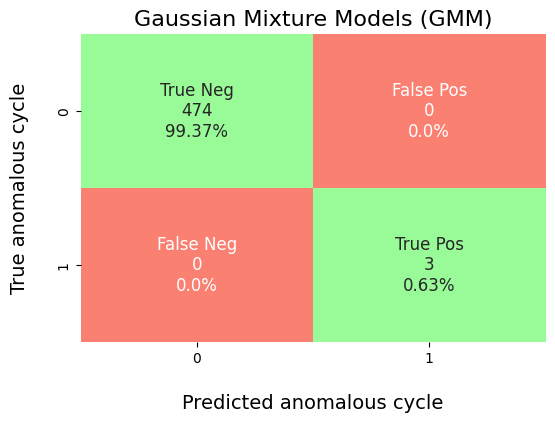

In [24]:
axplot = modval.generate_confusion_matrix(
    y_true=df_eval_outlier["true_outlier"],
    y_pred=df_eval_outlier["pred_outlier"])

axplot.set_title(
    "Gaussian Mixture Models (GMM)",
    fontsize=16)

output_fig_filename = (
    "conf_matrix_gmm_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Evaluate model performance

In [25]:
df_current_eval_metrics = modval.eval_model_performance(
    model_name="gmm",
    selected_cell_label=selected_cell_label,
    df_eval_outliers=df_eval_outlier)

df_current_eval_metrics

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
MCC-score: 1.0
****************************************************************************************************


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,gmm,cell_num_1,1.0,1.0,1.0,1.0,1.0


## Export model performance metrics to CSV output

In [26]:
# Export current metrics to CSV
hyperparam_eval_filepath =  Path.cwd().joinpath(
    "eval_metrics_hp_single_cell_tohoku.csv")

hp.export_current_model_metrics(
    model_name="gmm",
    selected_cell_label=selected_cell_label,
    df_current_eval_metrics=df_current_eval_metrics,
    export_csv_filepath=hyperparam_eval_filepath,
    if_exists="replace")

Have the metrics for gmm on cell cell_num_1 been evaluated before?
True
----------------------------------------------------------------------
Replacing existing row for gmm, cell_num_1.
Metrics for gmm, cell_num_1 have been replaced in the CSV file.


,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,lof,cell_num_1,1.0,1.0,1.0,1.0,1.0
1,pca,cell_num_1,1.0,1.0,1.0,1.0,1.0
2,autoencoder,cell_num_1,1.0,1.0,1.0,1.0,1.0
3,iforest,cell_num_1,1.0,1.0,1.0,1.0,1.0
4,knn,cell_num_1,1.0,1.0,1.0,1.0,1.0
5,gmm,cell_num_1,1.0,1.0,1.0,1.0,1.0


# Visualize predicted anomalies

## Plot predicted anomalies

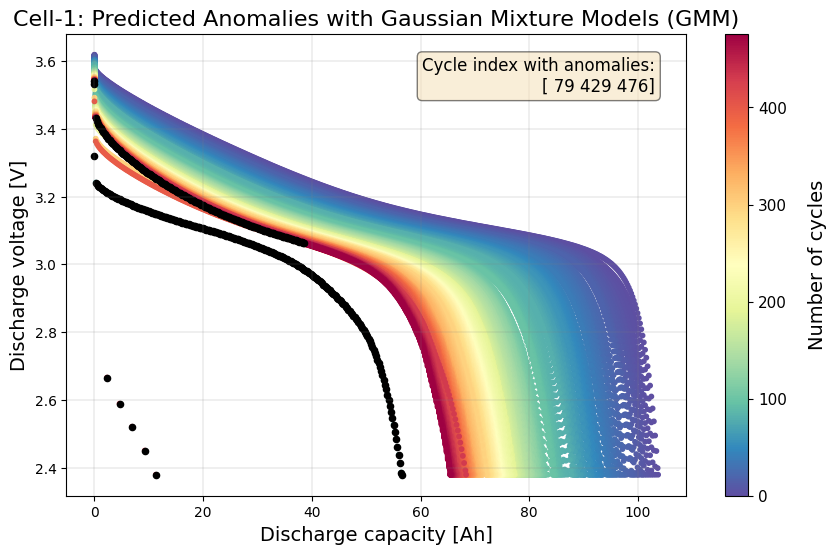

In [27]:
axplot = benchdb.plot_cycle_data(
    df_selected_cell_without_labels,
    pred_outlier_indices)

axplot.set_title(
    f"Cell-{cell_num}: Predicted Anomalies with Gaussian Mixture Models (GMM)",
    fontsize=16)

output_fig_filename = (
    "gmm_pred_cycles_with_outliers_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

## Plot predicted anomalies

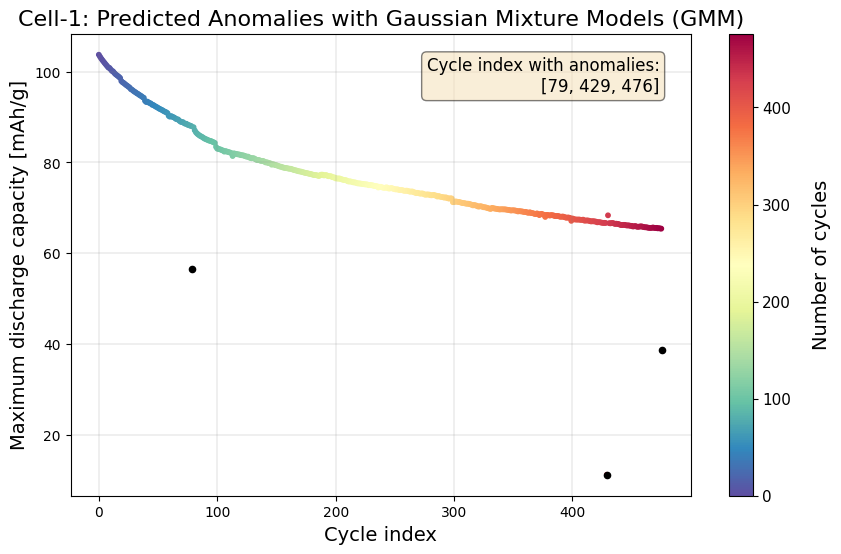

In [29]:
pred_cap_outlier = max_cap_per_cycle[
    max_cap_per_cycle
        .index.isin(pred_outlier_indices)]

axplot = bviz.plot_cycle_data(
    xseries=unique_cycle_index,
    yseries=max_cap_per_cycle,
    cycle_index_series=unique_cycle_index,
    xoutlier=pred_cap_outlier.index,
    youtlier=pred_cap_outlier)

axplot.set_xlabel(
    r"Cycle index",
    fontsize=14)
axplot.set_ylabel(
    r"Maximum discharge capacity [mAh/g]",
    fontsize=14)

axplot.set_title(
    f"Cell-{cell_num}: Predicted Anomalies with Gaussian Mixture Models (GMM)",
    fontsize=16)

# Create textbox to annotate anomalous cycle
textstr = '\n'.join((
    r"Cycle index with anomalies:",
    f"{list(pred_cap_outlier.index)}"))

# properties for bbox
props = dict(
    boxstyle='round',
    facecolor='wheat',
    alpha=0.5)

# first 0.95 corresponds to the left right alignment starting
# from left, second 0.95 corresponds to up down alignment
# starting from bottom
axplot.text(
    0.95, 0.95,
    textstr,
    transform=axplot.transAxes,
    fontsize=12,
    # ha means right alignment of the text
    ha="right", va='top',
    bbox=props)

output_fig_filename = (
    "gmm_pred_cap_fade_with_outliers_"
    + selected_cell_label
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()